In [4]:
import xarray as xr
import matplotlib as mpl
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import matplotlib.pyplot as plt
import scipy.signal as sig
import numpy as np
import cmocean as cmo

import sys
sys.path.append('../src')

from run import Run
from region import Region

import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Got run CESM2 Ross historical 1995-1996
Got run EC-Earth3 Ross historical 1995-1996
Got run UKESM1-0-LL Ross historical 1995-1996
Got run WOA23 Ross historical 1995-1996


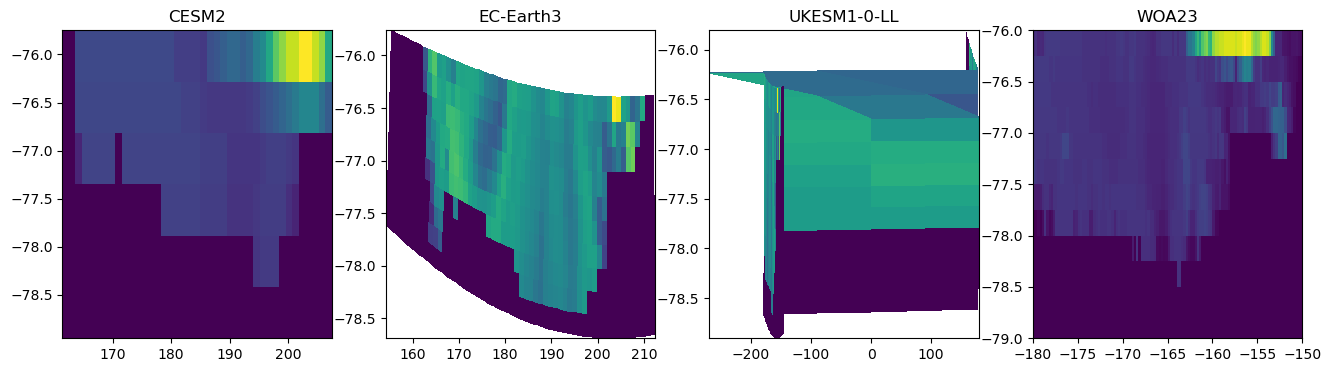

In [2]:
# Plot regions

fig,ax = plt.subplots(1,4,figsize=(16,4))

for m,mod in enumerate(['CESM2','EC-Earth3','UKESM1-0-LL','WOA23']):
    self = Run(mod,'Ross','historical',1995,1996)
    ax[m].pcolormesh(self.lon,self.lat,np.nansum(self.V,axis=0))
    #ax[m].pcolormesh(np.nansum(self.V,axis=0))
    ax[m].set_title(mod)

In [5]:
def get_series(region,years):
    Traw_av = np.zeros((len(years),len(region.prd.depth)))
    Tcor_av = np.zeros((len(years),len(region.ref.depth)))
    dTraw_av = np.zeros((len(years),len(region.prd.depth)))
    dTcor_av = np.zeros((len(years),len(region.ref.depth)))

    for y,year in enumerate(years):
        if year>2014:
            run = 'ssp585'
        else:
            run = 'historical'
        region.get_future(run,year,year+1)

        dTraw_av[y,:] = region.calc_horav(region.fut.dTraw,region.prd)
        Traw_av[y,:] = region.calc_horav(region.fut.T,region.fut)
        dTcor_av[y,:] = region.calc_horav(region.fut.dTcor,region.ref)
        Tcor_av[y,:] = region.calc_horav(region.ref.T+region.fut.dTcor,region.ref)
    return Traw_av,Tcor_av,dTraw_av,dTcor_av

def add_Tvar(fig,gs,n,m,zvar,var,years,title='',ylabel=''):
    ax = fig.add_subplot(gs[n,m])
    im = ax.pcolormesh(years,zvar,var.T,cmap='cmo.thermal',vmin=-2,vmax=3)
    ax.set_ylim([-1500,0])
    if m>0:
        ax.set_yticklabels([])
    ax.set_ylabel(ylabel)
    if n==0:
        ax.set_title(title)
    if n<2:
        ax.set_xticklabels([])
    return im

def add_dTvar(fig,gs,n,m,zvar,var,years,title=''):
    ax = fig.add_subplot(gs[n,m])
    im = ax.pcolormesh(years,zvar,var.T,cmap='cmo.balance',vmin=-4,vmax=4)
    ax.set_ylim([-1500,0])
    ax.set_yticklabels([])
    if n==0:
        ax.set_title(title)
    if n<2:
        ax.set_xticklabels([])
    return im

def add_row(fig,gs,n,regionname,years,model,refmodel):
    region = Region(regionname,model,refmodel,k0=50,k1=2000)
    Traw_av,Tcor_av,dTraw_av,dTcor_av = get_series(region,years)

    im = add_Tvar(fig,gs,n,0,region.prd.depth,Traw_av,years,title='Raw model',ylabel=region.model)
    im = add_Tvar(fig,gs,n,1,region.ref.depth,Tcor_av,years,title=f'Corrected (ref: {region.refmodel})')

    if n==0:
        ax = fig.add_subplot(gs[:,2])
        cb = plt.colorbar(im,cax=ax,extend='both')

    im = add_dTvar(fig,gs,n,4,region.prd.depth,dTraw_av,years,title='Raw model')
    im = add_dTvar(fig,gs,n,5,region.ref.depth,dTcor_av,years,title=f'Corrected')

    if n==0:
        ax = fig.add_subplot(gs[:,6])
        cb = plt.colorbar(im,cax=ax,extend='both')



Got run CESM2 Amundsen historical 1995-2015
Got run CESM2 Amundsen historical 1995-2015
Got run CESM2 Amundsen historical 1850-1851
Got run CESM2 Amundsen historical 1851-1852
Got run CESM2 Amundsen historical 1852-1853
Got run CESM2 Amundsen historical 1853-1854
Got run CESM2 Amundsen historical 1854-1855
Got run CESM2 Amundsen historical 1855-1856
Got run CESM2 Amundsen historical 1856-1857
Got run CESM2 Amundsen historical 1857-1858
Got run CESM2 Amundsen historical 1858-1859
Got run CESM2 Amundsen historical 1859-1860
Got run CESM2 Amundsen historical 1860-1861
Got run CESM2 Amundsen historical 1861-1862
Got run CESM2 Amundsen historical 1862-1863
Got run CESM2 Amundsen historical 1863-1864
Got run CESM2 Amundsen historical 1864-1865
Got run CESM2 Amundsen historical 1865-1866
Got run CESM2 Amundsen historical 1866-1867
Got run CESM2 Amundsen historical 1867-1868
Got run CESM2 Amundsen historical 1868-1869
Got run CESM2 Amundsen historical 1869-1870
Got run CESM2 Amundsen historica

Text(0.5, 0.98, 'Amundsen')

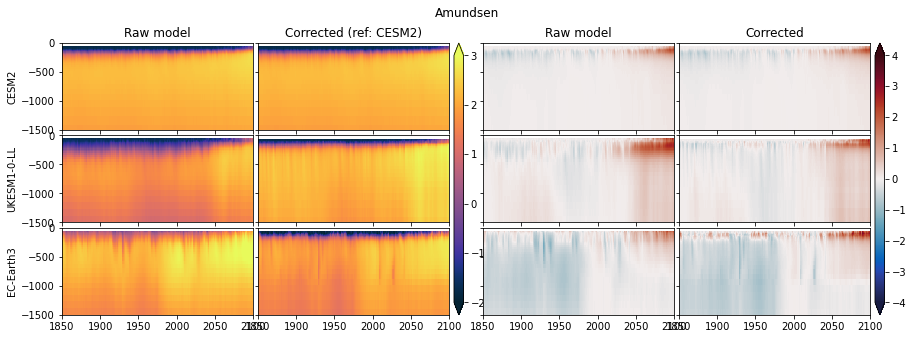

In [6]:
#years = np.arange(1850,2110,10)
years = np.arange(1850,2101,1)
refmodel = 'CESM2'
models = ['CESM2','UKESM1-0-LL','EC-Earth3']
#models = ['EC-Earth3']
regionname = 'Amundsen'

fig = plt.figure(figsize=(15,5))#,constrained_layout=True)
gs = GridSpec(3,8, figure=fig,
              width_ratios=[1,1,.05,.05,1,1,.05,.05],
              height_ratios=[1,1,1],wspace=.05,hspace=.06)

for n,model in enumerate(models):
    add_row(fig,gs,n,regionname,years,model,refmodel)

fig.suptitle(regionname)

In [ ]:
#years = np.arange(1850,2110,10)
years = np.arange(1850,2101,1)
refmodel = 'WOA23'
models = ['CESM2','UKESM1-0-LL','EC-Earth3']
#models = ['EC-Earth3']
regionname = 'Ross'

fig = plt.figure(figsize=(15,5))#,constrained_layout=True)
gs = GridSpec(3,8, figure=fig,
              width_ratios=[1,1,.05,.05,1,1,.05,.05],
              height_ratios=[1,1,1],wspace=.05,hspace=.06)

for n,model in enumerate(models):
    add_row(fig,gs,n,regionname,years,model,refmodel)

fig.suptitle(regionname)

In [ ]:
#years = np.arange(1850,2110,10)
years = np.arange(1850,2101,1)
refmodel = 'WOA23'
models = ['CESM2','UKESM1-0-LL','EC-Earth3']
#models = ['EC-Earth3']
regionname = 'Weddell'

fig = plt.figure(figsize=(15,5))#,constrained_layout=True)
gs = GridSpec(3,8, figure=fig,
              width_ratios=[1,1,.05,.05,1,1,.05,.05],
              height_ratios=[1,1,1],wspace=.05,hspace=.06)

for n,model in enumerate(models):
    add_row(fig,gs,n,regionname,years,model,refmodel)

fig.suptitle(regionname)

In [ ]:
#years = np.arange(1850,2110,10)
years = np.arange(1850,2101,1)
refmodel = 'WOA23'
models = ['CESM2','UKESM1-0-LL','EC-Earth3']
#models = ['EC-Earth3']
regionname = 'Totten'

fig = plt.figure(figsize=(15,5))#,constrained_layout=True)
gs = GridSpec(3,8, figure=fig,
              width_ratios=[1,1,.05,.05,1,1,.05,.05],
              height_ratios=[1,1,1],wspace=.05,hspace=.06)

for n,model in enumerate(models):
    add_row(fig,gs,n,regionname,years,model,refmodel)

fig.suptitle(regionname)

Got run CESM2 Amundsen historical 1995-2015
Got run EC-Earth3 Amundsen historical 1995-2015
Got run EC-Earth3 Amundsen ssp585 2050-2060


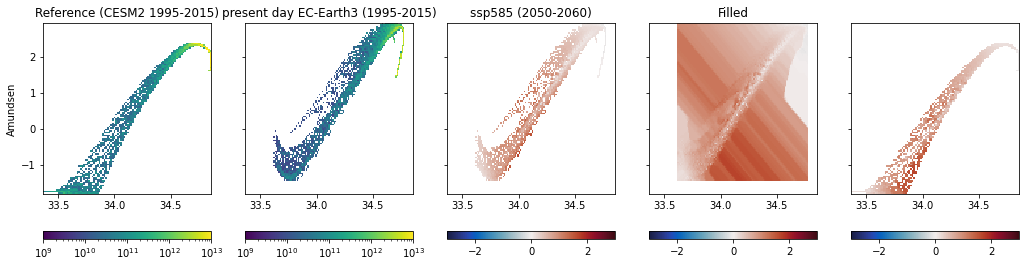

In [2]:
region = Region('Amundsen','EC-Earth3',refmodel='CESM2',k0=50,k1=2000)
region.get_future('ssp585',2050,2060)
region.plot_delta()

Got run WOA23 Totten historical 1995-2015
Got run CESM2 Totten historical 1995-2015
Got run CESM2 Totten ssp585 2050-2060


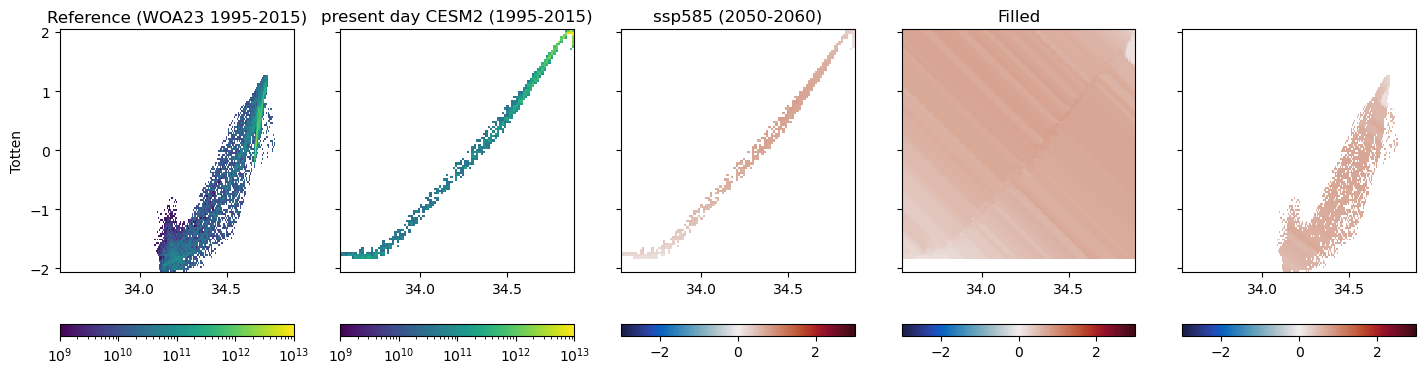

In [6]:
region = Region('Totten','CESM2',refmodel='WOA23',k0=50,k1=2000)
region.get_future('ssp585',2050,2060)
region.plot_delta()

In [ ]:
region = Region('Ross','EC-Earth3',refmodel='WOA23',k0=50,k1=2000)
region.get_future('ssp585',2050,2060)
region.plot_delta()